# EDA: Русскоязычные финансовые новости

**Задача**: бинарная классификация — позитивно ли новость может повлиять на фондовый рынок (`positive_market_impact`: 0/1)

**Данные**:
- Kaggle `kkhubiev/russian-financial-news` — 91 955 новостей
- GPT-4o разметка (`sentiment_score`) — 15 000 новостей
- Scraping smart-lab.ru + rbc.ru — 40 новостей
- **Merged**: `data/processed/financial_news_merged.csv` — 15 040 строк

In [1]:
import sys
import json
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

FIGDIR = '../data/reports'
import os
os.makedirs(FIGDIR, exist_ok=True)

print('Libraries loaded OK')

Libraries loaded OK


## 1. Загрузка данных

In [2]:
df = pd.read_csv('../data/processed/financial_news_merged.csv', encoding='utf-8-sig')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['title_len'] = df['title'].str.len()
df['body_len'] = df['body'].str.len()

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (15040, 11)
Columns: ['title', 'body', 'date', 'source', 'sentiment_score', 'article_type', 'sectors', 'tickers', 'positive_market_impact', 'title_len', 'body_len']


,title,body,date,source,sentiment_score,article_type,sectors,tickers,positive_market_impact,title_len,body_len
0,no title,"""После падения добычи в 2022-2023 годах Газпро...",2024-09-09,rdv,-0.5,finance,['Energy'],['GAZP'],0.0,8,828
1,no title,""" Рейтинг акций комьюнити РДВ. #опрос """,2024-09-09,rdv,0.0,advertising,[],[],0.0,8,41
2,no title,"""Нефть Brent упала до $71, Urals - до $60 за б...",2024-09-09,rdv,-0.5,finance,"['Energy', 'Financial Service']",[],0.0,8,842
3,no title,"""️ Ставка ЦБ вряд ли уйдёт выше 18%. ЦБ переже...",2024-09-09,rdv,0.0,opinions,"['Financial Service', 'Real Estate']",['MOEX'],0.0,8,973
4,no title,"""Эксперты клуба RDV PREMIUM 361° дали коммента...",2024-09-09,rdv,0.5,advertising,['Real Estate'],"['SMLT', 'ETLN', 'LSRG', 'PIKK']",1.0,8,1431


In [3]:
print('=== Типы данных ===')
print(df.dtypes)
print()
print('=== Пропуски ===')
print(df.isnull().sum())
print()
print('=== Базовая статистика ===')
df.describe()

=== Типы данных ===
title                             object
body                              object
date                      datetime64[ns]
source                            object
sentiment_score                  float64
article_type                      object
sectors                           object
tickers                           object
positive_market_impact           float64
title_len                          int64
body_len                           int64
dtype: object

=== Пропуски ===
title                      0
body                       0
date                       0
source                     0
sentiment_score           40
article_type              40
sectors                   40
tickers                   40
positive_market_impact    40
title_len                  0
body_len                   0
dtype: int64

=== Базовая статистика ===


,date,sentiment_score,positive_market_impact,title_len,body_len
count,15040,15000.000000,15000.000000,15040.000000,15040.000000
mean,2023-11-26 19:18:13.404255488,0.155768,0.490067,22.863697,741.307513
min,2022-05-26 00:00:00,-1.000000,0.000000,8.000000,7.000000
25%,2023-04-13 00:00:00,-0.100000,0.000000,8.000000,104.000000
50%,2024-02-09 00:00:00,0.000000,0.000000,8.000000,478.500000
75%,2024-07-03 00:00:00,0.500000,1.000000,38.000000,1014.000000
max,2026-03-26 00:00:00,1.000000,1.000000,146.000000,6710.000000
std,NaN,0.473322,0.499918,26.005366,828.046054


## 2. Целевая переменная

In [4]:
df_labeled = df[df['positive_market_impact'].notna()].copy()
df_labeled['positive_market_impact'] = df_labeled['positive_market_impact'].astype(int)

print(f'Размеченных строк: {len(df_labeled)}')
print(f'Нелабеленных строк: {df["positive_market_impact"].isna().sum()}')
print()
vc = df_labeled['positive_market_impact'].value_counts()
print('Распределение:')
print(vc)
print(f'\nБаланс: {vc[1]/len(df_labeled)*100:.1f}% позитивных')

Размеченных строк: 15000
Нелабеленных строк: 40

Распределение:
positive_market_impact
0    7649
1    7351
Name: count, dtype: int64

Баланс: 49.0% позитивных


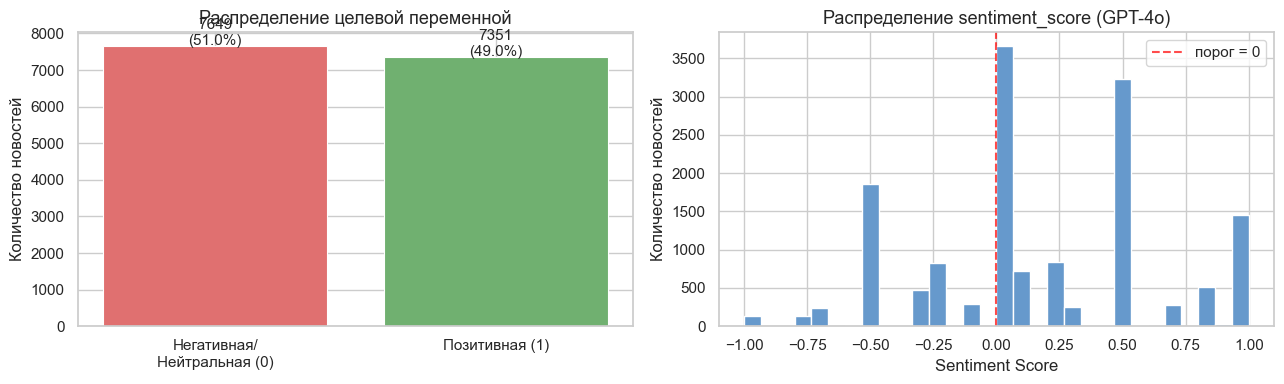

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
counts = df_labeled['positive_market_impact'].value_counts().sort_index()
axes[0].bar(
    ['Негативная/\nНейтральная (0)', 'Позитивная (1)'],
    counts.values,
    color=['#e07070', '#70b070'], edgecolor='white', linewidth=0.8
)
axes[0].set_title('Распределение целевой переменной', fontsize=13)
axes[0].set_ylabel('Количество новостей')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 40, f'{v}\n({v/len(df_labeled)*100:.1f}%)', ha='center', fontsize=11)

# Sentiment score histogram
axes[1].hist(df_labeled['sentiment_score'], bins=30, color='#6699cc', edgecolor='white')
axes[1].set_title('Распределение sentiment_score (GPT-4o)', fontsize=13)
axes[1].set_xlabel('Sentiment Score')
axes[1].set_ylabel('Количество новостей')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7, label='порог = 0')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_01_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Распределение по источникам

In [6]:
print('Источники:')
print(df['source'].value_counts())

Источники:
source
rdv                  5721
t_invest             4498
finam                3979
t_analytic            802
smart_lab_scraped      20
rbc_scraped            20
Name: count, dtype: int64


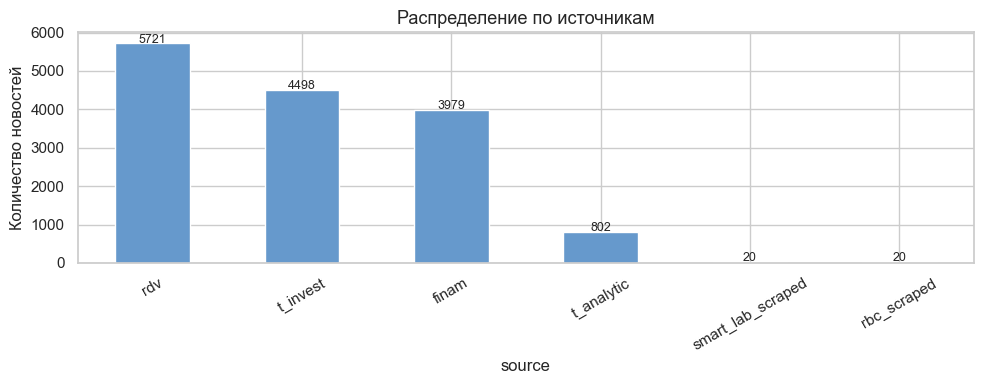

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
src_counts = df['source'].value_counts()
src_counts.plot(kind='bar', ax=ax, color='#6699cc', edgecolor='white')
ax.set_title('Распределение по источникам', fontsize=13)
ax.set_ylabel('Количество новостей')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(src_counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_02_sources.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Тип статьи vs сентимент

In [8]:
print('Типы статей:')
print(df_labeled['article_type'].value_counts())
print()
print('Доля позитивных по типу:')
print(df_labeled.groupby('article_type')['positive_market_impact'].mean().sort_values(ascending=False).round(3))

Типы статей:
article_type
finance               11653
advertising            1213
opinions                691
technical analysis      596
politics                466
others                  381
Name: count, dtype: int64

Доля позитивных по типу:
article_type
advertising           0.639
technical analysis    0.597
finance               0.505
opinions              0.369
politics              0.133
others                0.052
Name: positive_market_impact, dtype: float64


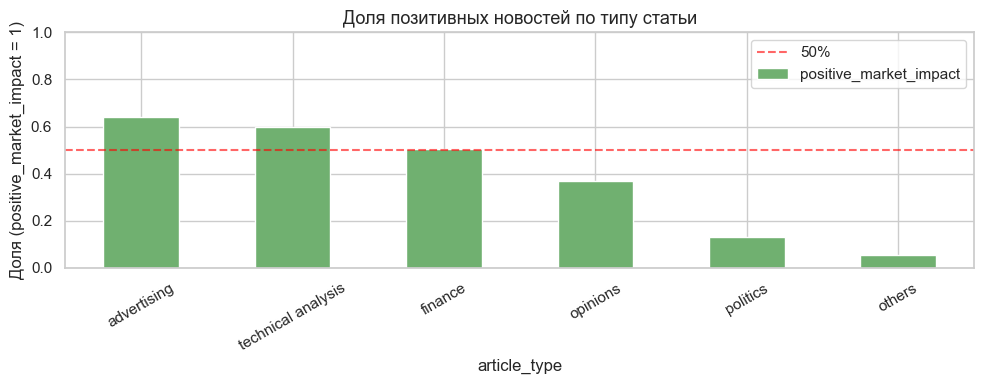

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
type_sent = df_labeled.groupby('article_type')['positive_market_impact'].mean().sort_values(ascending=False)
type_sent.plot(kind='bar', ax=ax, color='#70b070', edgecolor='white')
ax.set_title('Доля позитивных новостей по типу статьи', fontsize=13)
ax.set_ylabel('Доля (positive_market_impact = 1)')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=30)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.6, label='50%')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_03_article_type_sentiment.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Длина текстов

In [10]:
print('Длина заголовков (символов):')
print(df['title_len'].describe())
print()
print('Длина текста (символов):')
print(df['body_len'].describe())

Длина заголовков (символов):
count    15040.000000
mean        22.863697
std         26.005366
min          8.000000
25%          8.000000
50%          8.000000
75%         38.000000
max        146.000000
Name: title_len, dtype: float64

Длина текста (символов):
count    15040.000000
mean       741.307513
std        828.046054
min          7.000000
25%        104.000000
50%        478.500000
75%       1014.000000
max       6710.000000
Name: body_len, dtype: float64


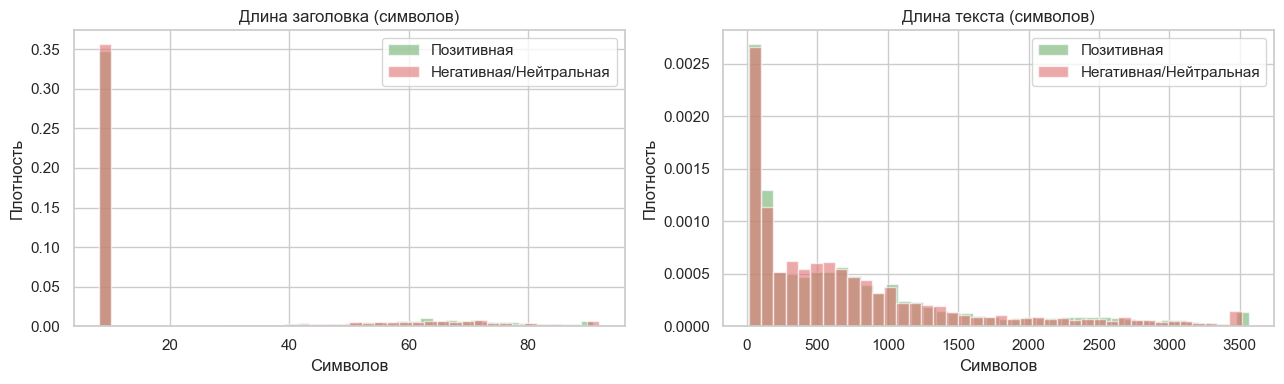

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for col, ax, label in [
    ('title_len', axes[0], 'Длина заголовка (символов)'),
    ('body_len', axes[1], 'Длина текста (символов)')
]:
    for val, color, lbl in [
        (1, '#70b070', 'Позитивная'),
        (0, '#e07070', 'Негативная/Нейтральная')
    ]:
        subset = df_labeled[df_labeled['positive_market_impact'] == val][col]
        subset = subset.clip(upper=subset.quantile(0.99))
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Символов')
    ax.set_ylabel('Плотность')
    ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_04_text_lengths.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Временная динамика

In [12]:
df_dated = df_labeled.dropna(subset=['date']).copy()
print(f'Строк с датой: {len(df_dated)}')
print(f'Период: {df_dated["date"].min().date()} — {df_dated["date"].max().date()}')

Строк с датой: 15000
Период: 2022-05-26 — 2024-12-15


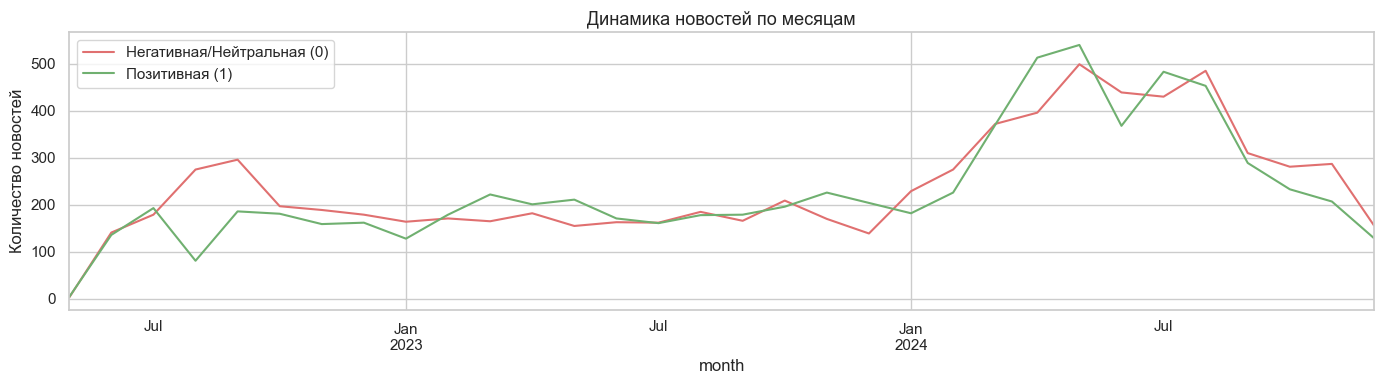

In [13]:
df_dated['month'] = df_dated['date'].dt.to_period('M')
monthly = df_dated.groupby(['month', 'positive_market_impact']).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(ax=ax, color=['#e07070', '#70b070'])
ax.set_title('Динамика новостей по месяцам', fontsize=13)
ax.set_ylabel('Количество новостей')
ax.legend(['Негативная/Нейтральная (0)', 'Позитивная (1)'])
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_05_time_dynamics.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Топ секторов экономики

In [14]:
import ast

all_sectors = []
for s in df_labeled['sectors'].dropna():
    try:
        parsed = ast.literal_eval(s) if isinstance(s, str) else s
        if isinstance(parsed, list):
            all_sectors.extend(parsed)
    except Exception:
        pass

sector_counts = Counter(all_sectors).most_common(15)
print('Топ-15 секторов:')
for s, c in sector_counts:
    print(f'  {s}: {c}')

Топ-15 секторов:
  Financial Service: 7456
  Energy: 4483
  Basic Materials: 2359
  Industrials: 2338
  Technology: 1834
  Consumer Cyclical: 1643
  Real Estate: 1225
  Consumer Defensive: 1202
  Communication Services: 829
  Utilities: 738
  Healthcare: 373
  Transportation: 14
  Industrial: 12
  Financial Services: 10
  Materials: 8


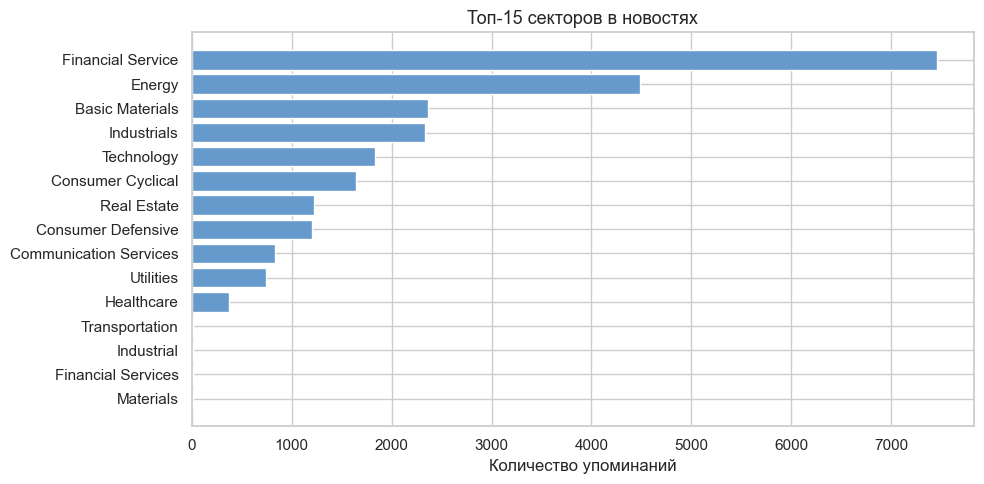

In [15]:
if sector_counts:
    sectors, counts = zip(*sector_counts)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(list(sectors)[::-1], list(counts)[::-1], color='#6699cc', edgecolor='white')
    ax.set_title('Топ-15 секторов в новостях', fontsize=13)
    ax.set_xlabel('Количество упоминаний')
    plt.tight_layout()
    plt.savefig(f'{FIGDIR}/fig_06_top_sectors.png', dpi=120, bbox_inches='tight')
    plt.show()

## 8. Итоговый Summary

In [16]:
print('=' * 55)
print('EDA SUMMARY')
print('=' * 55)
print(f'Всего строк:              {len(df):,}')
print(f'Размечено (GPT-4o):       {len(df_labeled):,}')
print(f'Не размечено (scraped):   {df["positive_market_impact"].isna().sum()}')
print()
print(f'Позитивных (impact=1):    {df_labeled["positive_market_impact"].sum():,} ({df_labeled["positive_market_impact"].mean()*100:.1f}%)')
print(f'Негативных/нейтр. (0):   {(df_labeled["positive_market_impact"]==0).sum():,} ({(df_labeled["positive_market_impact"]==0).mean()*100:.1f}%)')
print()
print(f'Средняя длина заголовка:  {df["title_len"].mean():.0f} символов')
print(f'Средняя длина текста:     {df["body_len"].mean():.0f} символов')
print(f'Период данных:            {df_dated["date"].min().date()} — {df_dated["date"].max().date()}')
print(f'Уникальных источников:    {df["source"].nunique()}')
print()
print('Типы статей:')
for t, c in df_labeled['article_type'].value_counts().items():
    print(f'  {t}: {c}')

EDA SUMMARY
Всего строк:              15,040
Размечено (GPT-4o):       15,000
Не размечено (scraped):   40

Позитивных (impact=1):    7,351 (49.0%)
Негативных/нейтр. (0):   7,649 (51.0%)

Средняя длина заголовка:  23 символов
Средняя длина текста:     741 символов
Период данных:            2022-05-26 — 2024-12-15
Уникальных источников:    6

Типы статей:
  finance: 11653
  advertising: 1213
  opinions: 691
  technical analysis: 596
  politics: 466
  others: 381
